In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(0)
df = np.random.exponential(size=1000,scale=2)
df = pd.DataFrame(df,columns=['values'])
df.head()

,values
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


<Axes: xlabel='values', ylabel='Count'>

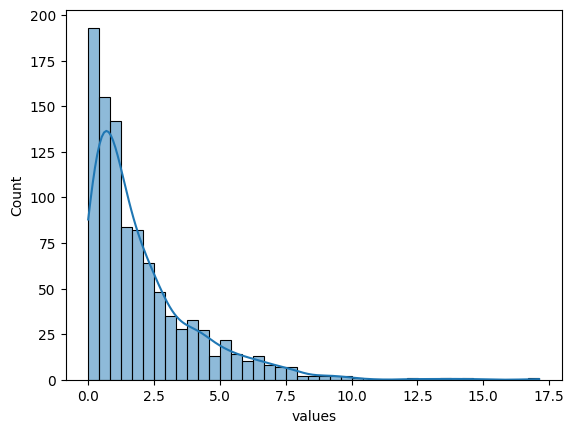

In [3]:
sns.histplot(df['values'] , kde=True)


## Box-cox & Yeo-johnson Transformer

In [4]:
from sklearn.preprocessing import PowerTransformer

#data must be positive for box-cox
pt_boxcox = PowerTransformer(method='box-cox', standardize=False)
pt_yeo_johnson = PowerTransformer(method='yeo-johnson')

df['Box_cox'] = pt_boxcox.fit_transform(df[['values']] + 1)
df['Yeo_johnson'] = pt_yeo_johnson.fit_transform(df[['values']])

In [5]:
df.head()

,values,Box_cox,Yeo_johnson
0,1.591749,0.787485,0.179335
1,2.511862,0.980233,0.677331
2,1.846446,0.849553,0.339698
3,1.574402,0.782945,0.167607
4,1.102097,0.639848,-0.202107


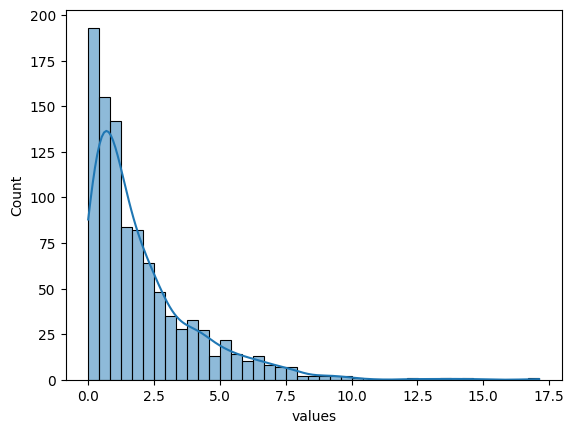

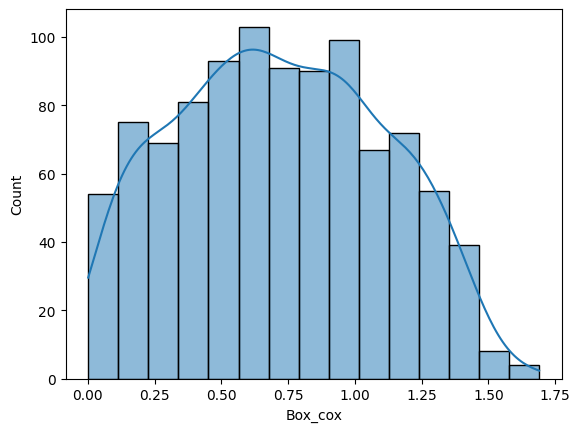

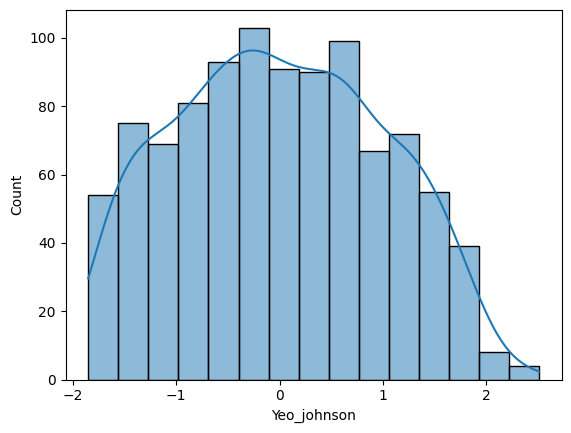

In [6]:
for col in df.columns:
    sns.histplot(df[col],kde=True)
    plt.show()

## Quantile Transformer

In [7]:
from sklearn.preprocessing import QuantileTransformer

qt_normal = QuantileTransformer(output_distribution='normal')

df['Quantile'] = qt_normal.fit_transform(df[['values']])

In [8]:
df.head()

,values,Box_cox,Yeo_johnson,Quantile
0,1.591749,0.787485,0.179335,0.162552
1,2.511862,0.980233,0.677331,0.587964
2,1.846446,0.849553,0.339698,0.286135
3,1.574402,0.782945,0.167607,0.157469
4,1.102097,0.639848,-0.202107,-0.154930


<Axes: xlabel='Quantile', ylabel='Count'>

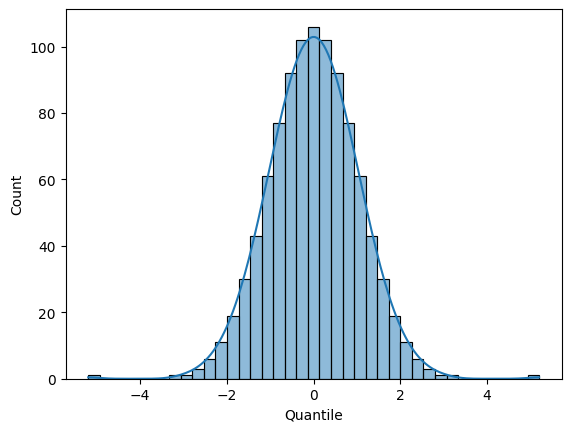

In [9]:
sns.histplot(df['Quantile'],kde=True)

## L2 Normalizer

In [15]:
from sklearn.preprocessing import Normalizer

data = [[1,2,3],[1,1,1],[2,2,0],[0,0,0]]
normalizer = Normalizer(norm='l2')
print(normalizer.fit_transform(data))


[[0.26726124 0.53452248 0.80178373]
 [0.57735027 0.57735027 0.57735027]
 [0.70710678 0.70710678 0.        ]
 [0.         0.         0.        ]]


## L1 Normalizer

In [17]:
from sklearn.preprocessing import Normalizer

data = [[1,2,3,1],[0,1,1,1],[2,6,2,0],[0,0,0,0]]
normalizer = Normalizer(norm='l1')
print(normalizer.fit_transform(data))

[[0.14285714 0.28571429 0.42857143 0.14285714]
 [0.         0.33333333 0.33333333 0.33333333]
 [0.2        0.6        0.2        0.        ]
 [0.         0.         0.         0.        ]]
